In [2]:
# aluno: Luiz Felipe Theodoro Carneiro - Matrícula: 200023349
# As informações sobre os resultados obtidos nesse programa e análise do gráfico estão disponíveis no PPC1.pdf, que pode ser baixado junto desse programa no github.

import matplotlib.pyplot as plt

def f(t, v, St, Re_s):
    """Lado direito da EDO adimensional (equação obtida na Tarefa 1 da APC)."""
    return (1.0 / St) * (1.0 - v - (3.0/8.0) * Re_s * v **2) # Representa o lado direito da equação diferencial adimensionalizada

def rk4_step(f, t, v, h, St, Re_s):
    """Um único passo do método Runge-Kutta de 4ª ordem clássico (eq. 13 do enunciado)."""
    k1 = f(t, v, St, Re_s) # inclinação da reta tangente no início do intervalo atual.
    k2 = f(t + 0.5*h, v + 0.5*h*k1, St, Re_s) # inclinação no ponto médio do intervalo, usando o valor estimado com k1.
    k3 = f(t + 0.5*h, v + 0.5*h*k2, St, Re_s) # outra estimativa da inclinação no ponto médio, agora usando k2.
    k4 = f(t + h, v + h*k3, St, Re_s) # inclinação no final do intervalo, usando k3.
    return v + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def solve_rk4(St, Re_s, v0=0.0, t_max=20.0, N=2000):
    """Resolve a EDO completa com RK4 usando apenas listas nativas do Python."""
    h = t_max / N # Calcula o tamanho do passo de integração
    t = [0.0] * (N + 1) # Cria uma lista de N+1 elementos (todos 0.0, isso serve para preparar o terreno,
                        # garantindo que a lista tem o tamanho correto já desde o início) para guardar os valores de tempo.
    v = [0.0] * (N + 1) # Cria outra lista de N+1 elementos para guardar as velocidades v*
    v[0] = v0 # Aplica a condição inicial: v*(0) = v0 (normalmente 0).
    for i in range(N): #Loop que executa exatamente N passos de integração (de i = 0 até i = N-1).
        v[i+1] = rk4_step(f, t[i], v[i], h, St, Re_s) # Chama a função rk4_step para calcular o próximo valor de velocidade v[i+1].
        t[i+1] = t[i] + h # Atualiza o tempo: soma o passo h (tempo avança de forma linear)
    return t, v #Retorna as duas listas completas: t (tempos) e v (velocidades).

def analytical_solution(t, St):
    """Solução analítica exata para Re_s → 0 (v* = 1 - exp(-t*/St))."""

    # Função interna que calcula e^x usando apenas fórmula matemática (série de Taylor)
    def exp_taylor(x):
        """Calcula exp(x) usando a série de Taylor (fórmula nativa do Python)"""
        result = 1.0          # termo inicial (n=0)
        term = 1.0
        for n in range(1, 40):   # 40 termos = precisão excelente para este problema
            term *= x / n        # termo seguinte = termo anterior * (x / n)
            result += term
        return result

    # Se t for uma lista (como o vetor t devolvido pelo solve_rk4)
    if isinstance(t, list):
        return [1.0 - exp_taylor(-ti / St) for ti in t]

    # Se t for um número único (escalar)
    else:
        return 1.0 - exp_taylor(-t / St)

# ====================== PARÂMETROS GERAIS ======================
t_max = 20.0
N_padrao = 2000

print("TAREFA 1: Comparação com solução analítica (Re_s → 0):")
St_values = [0.5, 1.0, 2.0]
for St in St_values:
    t, v_num = solve_rk4(St, 0.0, 0.0, t_max, N_padrao)
    v_ana = [analytical_solution(ti, St) for ti in t]
    max_err = max(abs(v_num[i] - v_ana[i]) for i in range(len(t)))
    print(f"St = {St:4.1f} | v*_terminal_num = {v_num[-1]:.6f} | "
          f"v*_terminal_ana = {v_ana[-1]:.6f} | erro_max = {max_err:.2e}")

print("\nTAREFA 2: Análise de refinamento temporal (variação de h):")
St_fix = 1.0
Re_s_fix = 0.0
N_values = [100, 500, 1000, 2000, 5000]
print("N     | h         | erro máximo")
print("-" * 35)
for N in N_values:
    h = t_max / N
    t, v_num = solve_rk4(St_fix, Re_s_fix, 0.0, t_max, N)
    v_ana = [analytical_solution(ti, St_fix) for ti in t]
    max_err = max(abs(v_num[i] - v_ana[i]) for i in range(len(t)))
    print(f"{N:5d} | {h:.6f} | {max_err:.2e}")

print("\nTAREFA 3: Caso com efeito inercial (Re_s ≠ 0):")
Re_s_values = [0.0, 0.1, 0.5, 1.0]
St_fix = 1.0
results = {}
for Re_s in Re_s_values:
    t, v = solve_rk4(St_fix, Re_s, 0.0, t_max, N_padrao)
    results[Re_s] = (t, v)
    print(f"Re_s = {Re_s:4.1f} | v*_terminal ≈ {v[-1]:.6f}")

print("\nTarefa 4: VALIDAÇÃO DA SOLUÇÃO NUMÉRICA")
print("\nUsando a solução analítica do documento (eq. 6) para Re_s → 0\n")

# Solução numérica (RK4)
t_num, v_num = solve_rk4(St, Re_s, v0=0.0, t_max=t_max, N=N)

# Solução analítica (do PDF)
v_ana = [analytical_solution(ti, St) for ti in t_num]

# Cálculo do erro máximo e médio
erros = [abs(v_num[i] - v_ana[i]) for i in range(len(t_num))]
erro_max = max(erros)
erro_medio = sum(erros) / len(erros)

print(f"Parâmetros usados: St = {St}, Re_s = {Re_s}, N = {N}, t_max = {t_max}")
print(f"Velocidade terminal (t* = {t_max}):")
print(f"   Numérica (RK4)   = {v_num[-1]:.8f}")
print(f"   Analítica (PDF)  = {v_ana[-1]:.8f}")
print(f"   Erro máximo      = {erro_max:.2e}")
print(f"   Erro médio       = {erro_medio:.2e}\n")

# Tabela comparativa (primeiros e últimos pontos + alguns intermediários)
print("Tabela comparativa:")
print("(    | t* | v*_numérica | v*_analítica | erro)")
print("-" * 65)
indices = [0, 200, 400, 800, 1200, 1600, 1999]  # pontos selecionados
for idx in indices:
    print(f"t* = {t_num[idx]:6.2f} | "
          f"{v_num[idx]:.6f} | "
          f"{v_ana[idx]:.6f} | "
          f"{erros[idx]:.2e}")

TAREFA 1: Comparação com solução analítica (Re_s → 0):
St =  0.5 | v*_terminal_num = 1.000000 | v*_terminal_ana = 7454992785195099.000000 | erro_max = 7.45e+15
St =  1.0 | v*_terminal_num = 1.000000 | v*_terminal_ana = 9034.771892 | erro_max = 9.03e+03
St =  2.0 | v*_terminal_num = 0.999955 | v*_terminal_ana = 0.999955 | erro_max = 9.84e-09

TAREFA 2: Análise de refinamento temporal (variação de h):
N     | h         | erro máximo
-----------------------------------
  100 | 0.200000 | 9.03e+03
  500 | 0.040000 | 9.03e+03
 1000 | 0.020000 | 9.03e+03
 2000 | 0.010000 | 9.03e+03
 5000 | 0.004000 | 9.03e+03

TAREFA 3: Caso com efeito inercial (Re_s ≠ 0):
Re_s =  0.0 | v*_terminal ≈ 1.000000
Re_s =  0.1 | v*_terminal ≈ 0.965074
Re_s =  0.5 | v*_terminal ≈ 0.861002
Re_s =  1.0 | v*_terminal ≈ 0.774852

Tarefa 4: VALIDAÇÃO DA SOLUÇÃO NUMÉRICA

Usando a solução analítica do documento (eq. 6) para Re_s → 0

Parâmetros usados: St = 2.0, Re_s = 1.0, N = 5000, t_max = 20.0
Velocidade terminal (t* 

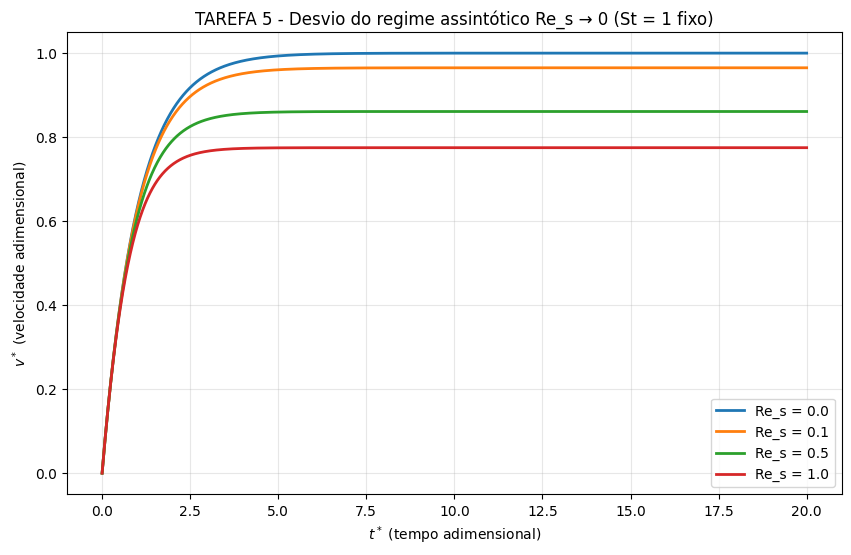

In [ ]:
# Gráfico 2 - Tarefa 5: efeito do número de Reynolds (St fixo = 1)
plt.figure(figsize=(10, 6))
for Re_s in Re_s_values:
    t, v = results[Re_s]
    plt.plot(t, v, linewidth=2, label=f'Re_s = {Re_s}')
plt.xlabel(r'$t^*$ (tempo adimensional)')
plt.ylabel(r'$v^*$ (velocidade adimensional)')
plt.title('TAREFA 5 - Desvio do regime assintótico Re_s → 0 (St = 1 fixo)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()